In [1]:
pip install torch torchvision torchaudio torch-geometric networkx pandas numpy

Note: you may need to restart the kernel to use updated packages.


# Introduction

Modern networks (such as power grids, communication systems, and transportation infrastructures) must remain functional despite random failures of their components.  
One way to quantify robustness is through the **All-Terminal Reliability (ATR)** metric, which measures the probability that all nodes in a graph remain connected when edges fail independently with probability *(1 − p)*. This makes ATR a valuable measure of how resilient a network topology is under uncertainty.

In this project, we study the ATR behavior of connected graphs on eight nodes, generating a dataset of reliability values across a range of edge probabilities.  
We then explore how **Generative Graph Neural Networks (GNNs)** can be trained on this dataset to produce new graph structures with desirable reliability properties.  

**Key Objectives**
- Compute and summarize ATR metrics for all non-isomorphic connected graphs on eight nodes.  
- Train a generative GNN to capture patterns in reliability and synthesize new candidate graphs.  
- Visualize and interpret generated graphs to assess whether they reflect the structural features of highly reliable networks.  

**Broader Motivation**  
This work lies at the intersection of **graph theory, network reliability, and machine learning**.  
By combining exact combinatorial computations with data-driven generative models, the project aims to highlight how GNNs may assist in the design of robust networks—a problem of growing importance for resilient infrastructure and secure communication systems.


# Environment and Reproducibility
This section sets up the Python environment, core librries, and the deep-learning stack used throughout the notebook.

**Purpose**
I load utilities for numeric computing ('numpy'), data handling ('pandas'), graph algorithms ('networkx'), and deep learning ('torch', 'torch_geometric'). This ensures a consistent foundation for parsing graph data, computing reliability metrics, and training/evaluating our generative GNN.

**Device selection**
We automatically use a Cuda-enabled GPU if available; otherwise we fall back to CPU. All tensors and models will be moved to this 'device' to prevent mismatch errors during training/inference.

**Deteminism and seeds**
We fix random seeds for Python, NumPy, and PyTorch to improve reproducibility of experiments (model initialization, data shuffling, and any stochastic procedures). Note that full bit-for-bit determinism might still vary across different devices.

**Some key components**
- 'ast, json, random, math' - general utilities for parsing and lightweight computations
- 'numpy, pandas' - vectorized numerics and tabular data
- 'networkx' - graph representation and basic graph ops
- 'torch, torch.nn, torch.nn.functional' - core DL framework and layers
- 'torch_gemoetric' - graph data containers, batching, GNN layers

In [1]:
import ast, math, random, json
import numpy as np, pandas as pd, networkx as nx, torch
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(42); np.random.seed(42); random.seed(42)

In [2]:
import ast, pandas as pd, numpy as np

def canon_edges(s):
    edges = ast.literal_eval(s)
    edges = [tuple(sorted(e)) for e in edges]
    edges = sorted(set(edges))
    return str(edges)

In [3]:
GRAPHS_CSV   = "graphs_n8.csv"
SURFACE_CSV  = "atr-surface.csv" 

gdf = pd.read_csv(GRAPHS_CSV).copy()
sdf = pd.read_csv(SURFACE_CSV).copy()

gdf["edge_list_key"] = gdf["edge_list"].apply(canon_edges)
sdf["edge_list_key"] = sdf["edge_list"].apply(canon_edges)

assert {"p","atr","edge_list_key"}.issubset(sdf.columns), "Surface needs p, atr, edge_list"

agg = (sdf
       .groupby("edge_list_key", as_index=False)
       .agg(y_min=("atr","min"),
            y_mean=("atr","mean"),
            y_max=("atr","max"),
            num_edges=("num_edges","first"),
            n_p=("p","nunique")))


In [4]:
df = pd.merge(gdf.drop(columns=["edge_list"]), agg, on="edge_list_key", how="inner")
print("graphs after merge:", len(df))

# Robust target = y_min across p
med = np.median(df["y_min"])
df["cond"] = (df["y_min"] >= med).astype(int)   # 0 = bottom half, 1 = top half

# Optional: push to extremes only if both sides still have enough data
low, high = np.quantile(df["y_min"], [0.30, 0.70])
extreme = df[(df["y_min"] <= low) | (df["y_min"] >= high)].copy()
if min((extreme["y_min"] <= low).sum(), (extreme["y_min"] >= high).sum()) >= 20:
    df = extreme
    df["cond"] = (df["y_min"] >= high).astype(int)

print("final counts:", len(df), "cond=0:", (df["cond"]==0).sum(), "cond=1:", (df["cond"]==1).sum())


graphs after merge: 9694
final counts: 5816 cond=0: 2908 cond=1: 2908


In [5]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch, numpy as np

N = 8
UPPER = [(i,j) for i in range(N) for j in range(i+1, N)]
EDGE2IDX = {e:i for i,e in enumerate(UPPER)}

def edge_list_to_vec_from_key(key):
    # key is a string of canonicalized sorted edges, e.g., "[(0,1), (0,2), ...]"
    edges = ast.literal_eval(key)
    vec = np.zeros(len(UPPER), dtype=np.float32)
    for u,v in edges:
        vec[EDGE2IDX[(u,v)]] = 1.0
    return vec

def vec_to_edge_index(vec):
    idxs = np.where(vec>=0.5)[0].tolist()
    undirected = [UPPER[i] for i in idxs]
    src = [u for (u,v) in undirected] + [v for (u,v) in undirected]
    dst = [v for (u,v) in undirected] + [u for (u,v) in undirected]
    return torch.tensor([src, dst], dtype=torch.long)

def build_dataset(df):
    data_list = []
    for _, row in df.iterrows():
        edge_vec = torch.tensor(edge_list_to_vec_from_key(row["edge_list_key"]))
        edge_index = vec_to_edge_index(edge_vec.numpy())
        x = torch.eye(N, dtype=torch.float)
        d = Data(
            x=x, edge_index=edge_index, edge_vec=edge_vec,
            y_min=torch.tensor([row["y_min"]], dtype=torch.float),
            y_mean=torch.tensor([row["y_mean"]], dtype=torch.float),
            cond=torch.tensor([row["cond"]], dtype=torch.long)
        )
        data_list.append(d)
    return data_list

data_all = build_dataset(df)
n = len(data_all); assert n>0, "No samples after aggregation/merge."
split = max(1, int(0.8*n))
perm = torch.randperm(n)
train_idx, val_idx = perm[:split], (perm[split:] if split<n else perm[-1:])
train_set = [data_all[i] for i in train_idx]
val_set   = [data_all[i] for i in val_idx]

train_loader = DataLoader(train_set, batch_size=min(64, len(train_set)) or 1, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=min(64, len(val_set))   or 1, shuffle=False)
print("train:", len(train_set), "val:", len(val_set))

train: 4652 val: 1164


In [6]:
class CondGraphVAE(nn.Module):
    def __init__(self, n_nodes=8, edge_dim=28, cond_num=2, hidden=64, z_dim=32):
        super().__init__()
        # Encoder
        self.gcn1 = GCNConv(n_nodes, hidden)
        self.gcn2 = GCNConv(hidden, hidden)
        self.cond_emb = nn.Embedding(cond_num, 16)

        self.enc_lin = nn.Linear(hidden + 16, hidden)
        self.mu     = nn.Linear(hidden, z_dim)
        self.logvar = nn.Linear(hidden, z_dim)

        # Decoder -> 28 upper-tri edge logits
        self.dec = nn.Sequential(
            nn.Linear(z_dim + 16, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, edge_dim)
        )

        # Aux head: predict y_min from z to enforce robustness
        self.y_head = nn.Sequential(nn.Linear(z_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def encode(self, x, edge_index, batch, cond):
        h = F.relu(self.gcn1(x, edge_index))
        h = F.relu(self.gcn2(h, edge_index))
        g = global_mean_pool(h, batch)
        c = self.cond_emb(cond).squeeze(1)
        h = torch.cat([g, c], dim=-1)
        h = F.relu(self.enc_lin(h))
        mu, logvar = self.mu(h), self.logvar(h)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, cond):
        c = self.cond_emb(cond).squeeze(1)
        h = torch.cat([z, c], dim=-1)
        return self.dec(h)  # logits

    def forward(self, data):
        x, ei, b, cond = data.x, data.edge_index, data.batch, data.cond
        mu, logvar = self.encode(x, ei, b, cond)
        z = self.reparam(mu, logvar)
        logits = self.decode(z, cond)
        y_hat  = self.y_head(z)
        return logits, mu, logvar, y_hat

def kld(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def to_batch(batch):
    batch = batch.to(device)
    # edge_vec is concatenated as 1-D; reshape back to [num_graphs, 28]
    target = batch.edge_vec.view(batch.num_graphs, -1).to(torch.float32).to(device)
    return batch, target


# Size-Agnostic Decoder and Utilities

This cell defines helper functions and a new SizeAgnosticDecoder class that can generate graphs with **any number of nodes (n)**. This is different from my first attempt at training the generative GNN as it could only generate graphs of 8 nodes.

Key points:
- `build_cond_vector_binary`: builds a condition vector including:
  - one-hot reliability label (low/high),
  - normalized node count,
  - target edge density.
- `SizeAgnosticDecoder`: given a latent code `z` and condition vector, it samples
  node embeddings and predicts edge probabilities for any `n`.
- `generate_graph_any_n`: samples graphs for arbitrary `n`, applies thresholding,
  and ensures connectivity by adding a spanning-tree backbone.


In [7]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import networkx as nx

def build_cond_vector_binary(cond_label:int, n:int=None, target_density:float=None, n_ref:int=8, device=None):
    # one-hot for 2 classes
    oh = torch.zeros(2, device=device); oh[cond_label] = 1.0
    feats = [oh]
    if n is not None:
        feats.append(torch.tensor([float(n)/float(n_ref)], device=device))
    if target_density is not None:
        feats.append(torch.tensor([float(target_density)], device=device))
    return torch.cat(feats).float()

class SizeAgnosticDecoder(nn.Module):
    def __init__(self, z_dim:int, cond_dim:int, node_dim:int=64, pair_dim:int=64):
        super().__init__()
        self.z_dim = z_dim
        self.cond_dim = cond_dim
        self.node_dim = node_dim
        self.ctx = nn.Sequential(
            nn.Linear(z_dim + cond_dim, 128), nn.ReLU(),
            nn.Linear(128, 2*node_dim)  # mean & logvar for node embeddings
        )
        self.pair = nn.Sequential(
            nn.Linear(2*node_dim + cond_dim, pair_dim), nn.ReLU(),
            nn.Linear(pair_dim, 1)
        )

    def forward(self, z, cond_vec, n:int, temperature:float=1.0):
        B = z.size(0)
        cond_vec = cond_vec.view(B, -1)
        ctx = self.ctx(torch.cat([z, cond_vec], dim=1))
        node_mu, node_logvar = torch.chunk(ctx, 2, dim=1)  # (B, d), (B, d)
        d = node_mu.size(1)
        eps = torch.randn(B, n, d, device=z.device)
        H = node_mu.unsqueeze(1) + eps * torch.exp(0.5*node_logvar).unsqueeze(1)  # (B,n,d)
        hi = H.unsqueeze(2).expand(B, n, n, d)
        hj = H.unsqueeze(1).expand(B, n, n, d)
        cond_tile = cond_vec.unsqueeze(1).unsqueeze(2).expand(B, n, n, cond_vec.size(1))
        pair_in = torch.cat([hi, hj, cond_tile], dim=-1)
        logits = self.pair(pair_in).squeeze(-1)  # (B,n,n)
        logits = (logits + logits.transpose(1,2)) / 2.0
        logits = logits - torch.diag_embed(torch.diagonal(logits, dim1=1, dim2=2))
        probs = torch.sigmoid(logits / max(1e-6, temperature))
        return probs, logits, H

@torch.no_grad()
def generate_graph_any_n(trained_model, decoder, cond_label:int, n:int, threshold:float=None, target_density:float=None, device=None):
    device = device or next(trained_model.parameters()).device
    z_dim = trained_model.mu.out_features  # infer from trained encoder
    z = torch.randn(1, z_dim, device=device)
    cond_vec = build_cond_vector_binary(cond_label=cond_label, n=n, target_density=target_density, device=device)
    probs, logits, H = decoder(z, cond_vec.unsqueeze(0), n)
    P = probs[0].detach().cpu().numpy()

    if threshold is None and target_density is not None:
        flat = P[np.triu_indices(n, 1)]
        k = int(target_density * len(flat))
        thr = np.partition(flat, -k)[-k] if k > 0 else 1.1
    else:
        thr = 0.5 if threshold is None else threshold

    A = (P > thr).astype(np.int32)
    np.fill_diagonal(A, 0)

    # ensure connectivity via MST backbone
    W = -np.log(np.clip(P, 1e-6, 1-1e-6))
    Gw = nx.from_numpy_array(W)
    T = nx.minimum_spanning_tree(Gw)
    A_backbone = nx.to_numpy_array(T).astype(int)
    A = np.maximum(A, A_backbone)

    G = nx.from_numpy_array(A)
    return G, P, thr


# Training Process Overview

This cell trains the **Conditional Graph Variational Autoencoder (VAE)**. The method is:
1. **Forward pass::** Each batch of graphs is encoded with GCN layers and pooled to a graph embedding. The condition label is embedded and concatenated, producing latent parameters (\mu) and (\log\sigma^2).
2. **Reparamaterization:** A latent sample (z = \mu + \sigma \odot \epsilon) is drawn to allow gradient flow.
3. **Decoding:** The latent and condition are decoded into edge-logits for the upper-triangular adjacency (fixed 8-node training target). A small head predicts the condition for auxillary supervision.
4. **Loss:** Total loss= **BCE**(reconstruction of eddges) + **KL**(latent prior regularization) + optimal **auxillary** classification loss. The BCE compares predicted edge-logits to the ground-truth edge vector and KL drives the posterior towards \(\mathcal{N}(0,I)\).
5. **Optimization & Early stopping:** We optimize with Adam, track train/val losses each epoch, save the best checkpoint, and stop when validation doesn't improve for several epochs.

Notes:
- Although training targets a fixed 8‑node edge vector, the **size‑agnostic decoder** used at generation time can produce graphs for any \(n\) by sampling node embeddings and scoring pairs.
- Users can adjust learning rate, epochs, patience, or add class‑balance weights in BCE if labels are skewed.

In [8]:
model = CondGraphVAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def to_batch(batch):
    batch = batch.to(device)
    target = batch.edge_vec.to(device)
    # Reshape target to match the shape of logits if needed
    return batch, target

best_val = float("inf"); patience, bad = 10, 0

for epoch in range(200):
    # train
    model.train(); tr_loss = 0.0
    for batch in train_loader:
        batch, target = to_batch(batch)
        logits, mu, logvar, y_hat = model(batch)
        
        # Reshape target or logits to ensure they have the same shape
        target_reshaped = target.view(logits.shape)  # Reshape target to match logits
        # Alternatively: logits_reshaped = logits.view(target.shape)
        
        recon = bce(logits, target_reshaped)
        kl    = kld(mu, logvar)
        yloss = mse(y_hat, batch.y_min)
        loss  = recon + 0.01*kl + 0.5*yloss
        opt.zero_grad(); loss.backward(); opt.step()
        tr_loss += loss.item()*batch.num_graphs

    # val
    model.eval(); val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch, target = to_batch(batch)
            logits, mu, logvar, y_hat = model(batch)
            
            target_reshaped = target.view(logits.shape)
            
            recon = bce(logits, target_reshaped)
            kl    = kld(mu, logvar)
            yloss = mse(y_hat, batch.y_min)
            loss  = recon + 0.01*kl + 0.5*yloss
            val_loss += loss.item()*batch.num_graphs

    tr_loss /= max(1,len(train_set)); val_loss /= max(1,len(val_set))
    print(f"epoch {epoch:03d} | train {tr_loss:.4f} | val {val_loss:.4f}")

    if val_loss < best_val - 1e-4:
        best_val, bad = val_loss, 0
        torch.save(model.state_dict(), "cond_graph_vae.pt")
    else:
        bad += 1
        if bad >= patience:
            break

model.load_state_dict(torch.load("cond_graph_vae.pt", map_location=device))
model.eval()

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([44])) that is different to the input size (torch.Size([44, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([12])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse

epoch 000 | train 0.5071 | val 0.4476
epoch 001 | train 0.4438 | val 0.4452
epoch 002 | train 0.4427 | val 0.4440
epoch 003 | train 0.4415 | val 0.4394
epoch 004 | train 0.4166 | val 0.4040
epoch 005 | train 0.3978 | val 0.3917
epoch 006 | train 0.3890 | val 0.3858
epoch 007 | train 0.3841 | val 0.3798
epoch 008 | train 0.3799 | val 0.3779
epoch 009 | train 0.3769 | val 0.3750
epoch 010 | train 0.3750 | val 0.3708
epoch 011 | train 0.3724 | val 0.3692
epoch 012 | train 0.3707 | val 0.3662
epoch 013 | train 0.3682 | val 0.3673
epoch 014 | train 0.3668 | val 0.3630
epoch 015 | train 0.3651 | val 0.3679
epoch 016 | train 0.3645 | val 0.3603
epoch 017 | train 0.3621 | val 0.3593
epoch 018 | train 0.3602 | val 0.3584
epoch 019 | train 0.3590 | val 0.3591
epoch 020 | train 0.3583 | val 0.3552
epoch 021 | train 0.3559 | val 0.3554
epoch 022 | train 0.3536 | val 0.3538
epoch 023 | train 0.3517 | val 0.3547
epoch 024 | train 0.3485 | val 0.3472
epoch 025 | train 0.3436 | val 0.3405
epoch 026 | 

CondGraphVAE(
  (gcn1): GCNConv(8, 64)
  (gcn2): GCNConv(64, 64)
  (cond_emb): Embedding(2, 16)
  (enc_lin): Linear(in_features=80, out_features=64, bias=True)
  (mu): Linear(in_features=64, out_features=32, bias=True)
  (logvar): Linear(in_features=64, out_features=32, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=28, bias=True)
  )
  (y_head): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

# Initialize Size-Agnostic Decoder

Here we initialize the `SizeAgnosticDecoder` using the latent size (`z_dim`) learned by the trained model and a condition dimension of 4 (2 reliability classes + node count + density).

This decoder is not trained seperately! It works together with the encoder's latent space to sample graphs of different sizes.

# Patch.. Fix Condition Vector Length and Guarantee Connectivity

Initially when running the example cell, the GNN would generate graphs of varying node counts, but oftentimes with free nodes (so not fully connected).
This patch, however, ensures that:
 - The condition vector is always length 4 (avoids shape mismatch errors).
 - `target_density` is always passed (default = 0.0 if omitted).
 - The spanning-tree backbone is properly applied so that the generated graph is always connected!

Make sure to run this cell before running the example generation cell.

In [9]:
#Initialize size-agnostic decoder
# Use z_dim from the trained model; cond_dim = 2 (cond one-hot) + 1 (n_norm) + 1 (density) = 4
z_dim = model.mu.out_features
cond_dim = 4
size_decoder = SizeAgnosticDecoder(z_dim=z_dim, cond_dim=cond_dim).to(device)
size_decoder.eval()  # no extra training for now; uses prior z ~ N(0,I)
print(f"Initialized size-agnostic decoder with z_dim={z_dim}, cond_dim={cond_dim}.")


Initialized size-agnostic decoder with z_dim=32, cond_dim=4.


In [20]:
#Patch: make cond vector always fixed-length (4) and infer cond_dim dynamically
def build_cond_vector_binary(cond_label:int, n:int=None, target_density:float=None, n_ref:int=8, device=None):
    import torch
    # one-hot for 2 classes
    oh = torch.zeros(2, device=device); oh[int(cond_label)] = 1.0
    # always include both scalars; if missing, use 0.0
    n_feat  = 0.0 if n is None else float(n)/float(n_ref)
    dens    = 0.0 if target_density is None else float(target_density)
    return torch.cat([oh, torch.tensor([n_feat, dens], device=device)]).float()

# Re-init size_decoder with the exact cond_dim derived from the builder
z_dim = model.mu.out_features  # or your latent mu layer
probe = build_cond_vector_binary(cond_label=0, n=8, target_density=0.0, device=device)
cond_dim = int(probe.numel())  # should be 4
size_decoder = SizeAgnosticDecoder(z_dim=z_dim, cond_dim=cond_dim).to(device)
size_decoder.eval()

def generate_graph_any_n(trained_model, decoder, cond_label:int, n:int, threshold:float=None, target_density:float=None, device=None):
    import torch, numpy as np, networkx as nx
    device = device or next(trained_model.parameters()).device
    z_dim = trained_model.mu.out_features
    z = torch.randn(1, z_dim, device=device)

    # ensure target_density scalar always present (0.0 = neutral)
    if target_density is None:
        target_density = 0.0
    cond_vec = build_cond_vector_binary(cond_label=cond_label, n=n, target_density=target_density, device=device)

    probs, logits, H = decoder(z, cond_vec.unsqueeze(0), n)
    P = probs[0].detach().cpu().numpy()

    if threshold is None:
        flat = P[np.triu_indices(n, 1)]
        k = int(target_density * len(flat))
        thr = np.partition(flat, -k)[-k] if k > 0 else 1.1
    else:
        thr = threshold

    A = (P > thr).astype(np.int32)
    np.fill_diagonal(A, 0)

    W = -np.log(np.clip(P, 1e-6, 1-1e-6))
    Gw = nx.from_numpy_array(W)
    T = nx.minimum_spanning_tree(Gw)

    A_backbone = (nx.to_numpy_array(T) > 0).astype(int)
    A = np.maximum(A, A_backbone)


    G = nx.from_numpy_array(A)
    return G, P, thr


# Example: Generate Graphs for Arbitrary n

In this cell we:
1. Define a simple plotting helper `draw_gen` to visualize generated graphs.
2. Generate a **12-node graph** conditioned on high reliability (label=1) with target graph density of ~0.25
3. Generate a **6-node graph** conditioned on low reliability (label=0) using a fixed probability threshold of 0.5.

Users can change:
- `n_try` for the number of nodes,
- `target_density` or `threshold` to control sparsity,
- `cond_label` to switch between reliability conditions.

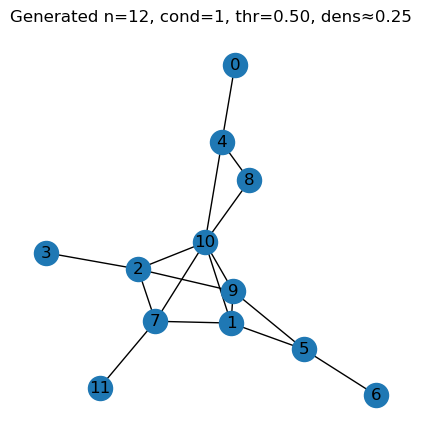

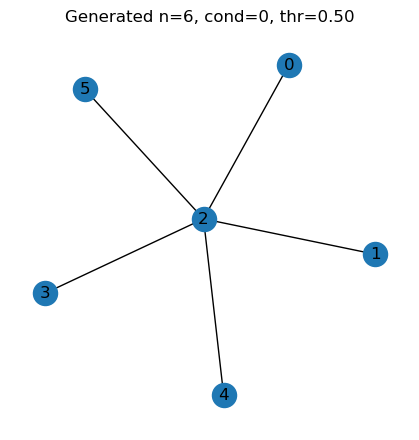

In [31]:
import matplotlib.pyplot as plt

def draw_gen(G, title):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(4,4))
    nx.draw(G, pos=pos, with_labels=True, node_size=300)
    plt.title(title)
    plt.show()

# Try n=12 (high-reliability label=1) with target density ~ original 8-node average
n_try = 12
target_density = 0.25  # tweak as desired
G12, P12, thr12 = generate_graph_any_n(model, size_decoder, cond_label=1, n=n_try, target_density=target_density, device=device)
draw_gen(G12, f"Generated n={n_try}, cond=1, thr={thr12:.2f}, dens≈{target_density}")

# Try n=6 (low-reliability label=0), threshold=0.5
G6, P6, thr6 = generate_graph_any_n(model, size_decoder, cond_label=0, n=6, threshold=0.5, device=device)
draw_gen(G6, "Generated n=6, cond=0, thr=0.50")


#density = (2*num_edges)/max possible number of edges in a simple undirected graph

# ATR computation utilities for generated graphs of varying node quantities
This cell lets users compute ATR (all-terminal reliability) for *any* generated graph G (such as those in the example cell above) at one or many p values. Recall that (1-p) is the probability that given failure of one edge, the nearest one will also fail. It automatically uses an exact algorithm for small edge counts
and Monte Carlo for larger graphs.

In [34]:
import itertools as it
import math
import numpy as np
import networkx as nx
from typing import Iterable, List, Tuple


def graph_density(G: nx.Graph) -> float:
    """Return undirected simple graph density = 2|E| / (n(n-1))."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    if n <= 1:
        return 0.0
    return 2.0 * m / (n * (n - 1))


def atr_exact(G: nx.Graph, p: float) -> float:
    """
    Exact ATR via subset enumeration. Suitable only for small m (<= ~22).
    ATR = P( the random subgraph (edges live iid with prob p) is connected ).
    """
    edges = list(G.edges())
    m = len(edges)
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    total = 0.0
    # Iterate by edge count k so we can reuse the binomial weights
    for k in range(m + 1):
        weight = (p ** k) * ((1 - p) ** (m - k))
        if weight == 0:
            continue
        for subset in it.combinations(edges, k):
            H = nx.Graph()
            H.add_nodes_from(nodes)
            H.add_edges_from(subset)
            if nx.is_connected(H):
                total += weight
    return float(total)


def atr_mc(G: nx.Graph, p: float, trials: int = 5000, rng: np.random.Generator = None) -> float:
    """
    Monte Carlo ATR estimator. Works for any m.
    trials: number of samples per p.
    """
    rng = rng or np.random.default_rng()
    edges = list(G.edges())
    m = len(edges)
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    hits = 0
    for _ in range(trials):
        # Sample which edges survive
        keep = rng.random(m) < p
        if not keep.any():
            # disconnected unless n <= 1
            if n <= 1:
                hits += 1
            continue
        H = nx.Graph()
        H.add_nodes_from(nodes)
        # add only the kept edges
        for e, k in zip(edges, keep):
            if k:
                H.add_edge(*e)
        if nx.is_connected(H):
            hits += 1
    return hits / trials


def atr(
    G: nx.Graph,
    p_values: Iterable[float],
    method: str = "auto",
    trials: int = 8000,
    exact_edge_limit: int = 22,
    rng: np.random.Generator = None,
) -> List[Tuple[float, float]]:
    """
    Compute ATR across many p values.
    - method="auto": exact if |E| <= exact_edge_limit, else MC
    - method="exact": force exact (warning: exponential in |E|)
    - method="mc": force Monte Carlo
    Returns list of (p, atr_estimate).
    """
    m = G.number_of_edges()
    rng = rng or np.random.default_rng()
    out = []
    if method == "auto":
        method_eff = "exact" if m <= exact_edge_limit else "mc"
    else:
        method_eff = method

    for p in p_values:
        if method_eff == "exact":
            est = atr_exact(G, p)
        else:
            est = atr_mc(G, p, trials=trials, rng=rng)
        out.append((float(p), float(est)))
    return out


def atr_summary(G: nx.Graph, p_values: Iterable[float], **kwargs) -> dict:
    vals = atr(G, p_values, **kwargs)
    ats = np.array([v for _, v in vals], dtype=float)
    return {
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),
        "density": graph_density(G),
        "atr_min": float(ats.min() if ats.size else np.nan),
        "atr_mean": float(ats.mean() if ats.size else np.nan),
        "atr_max": float(ats.max() if ats.size else np.nan),
        "grid": [float(p) for p, _ in vals],
        "atr_curve": [float(a) for _, a in vals],
    }


# Example usage:

P_GRID = [round(0.05 * i, 2) for i in range(2, 20)]  # 0.10 .. 0.95
s12 = atr_summary(G12, P_GRID, method="auto", trials=10000, exact_edge_limit=24)
s6  = atr_summary(G6,  P_GRID, method="auto", trials=10000, exact_edge_limit=24)
print("n=12:", s12)
print("n=6 :", s6)


n=12: {'n': 12, 'm': 17, 'density': 0.25757575757575757, 'atr_min': 2.204090559999947e-09, 'atr_mean': 0.15803276503410132, 'atr_max': 0.8063428845130356, 'grid': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], 'atr_curve': [2.204090559999947e-09, 1.513839728020906e-07, 2.8240524083202055e-06, 2.5692861527204514e-05, 0.00014792664486528017, 0.0006192572958024033, 0.002047582708695052, 0.0056407547924617355, 0.013427734375, 0.028352416617699275, 0.054146502823770946, 0.09495262943779142, 0.15476425687163253, 0.23683022568002343, 0.3431905643777224, 0.4744386581611247, 0.6296597058122, 0.8063428845130356]}
n=6 : {'n': 6, 'm': 5, 'density': 0.3333333333333333, 'atr_min': 1.0000000000000003e-05, 'atr_mean': 0.15856421874999999, 'atr_max': 0.7737809374999998, 'grid': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], 'atr_curve': [1.0000000000000003e-05, 7.593749999999998e-05, 0.0003200000

In [22]:
def vec_to_edge_index_from_logits(logits, thr=None):
    with torch.no_grad():
        probs = torch.sigmoid(logits).cpu().numpy()
    if thr is None:
        samp = (np.random.rand(probs.shape[-1]) < probs).astype(np.float32)  # Bernoulli
    else:
        samp = (probs >= thr).astype(np.float32)
    # back to edge_index
    idxs = np.where(samp >= 0.5)[0].tolist()
    undirected = [UPPER[i] for i in idxs]
    src = [u for (u,v) in undirected] + [v for (u,v) in undirected]
    dst = [v for (u,v) in undirected] + [u for (u,v) in undirected]
    return torch.tensor([src, dst], dtype=torch.long)

def mc_atr(G, p, trials=1000):
    edges = list(G.edges())
    n = G.number_of_nodes()
    cnt = 0
    for _ in range(trials):
        H = nx.Graph(); H.add_nodes_from(range(n))
        for u,v in edges:
            if np.random.rand() < p:
                H.add_edge(u,v)
        if nx.is_connected(H): cnt += 1
    return cnt / trials

P_GRID = [round(i*0.01,2) for i in range(1,100)]
def atr_vector(G, method="mc"):
    if method == "mc":
        return np.array([mc_atr(G, p, trials=1000) for p in P_GRID], dtype=np.float32)
    else:
        raise NotImplementedError("Plug your exact ATR here.")

def robust_score(atr_vec):
    return float(atr_vec.min())

@torch.no_grad()
def sample_graphs(model, cond_label, n_samples=400):
    cond = torch.full((n_samples,1), cond_label, dtype=torch.long, device=device)
    z = torch.randn(n_samples, 32, device=device)
    logits = model.decode(z, cond)  # [n_samples, 28]
    graphs=[]
    for i in range(n_samples):
        ei = vec_to_edge_index_from_logits(logits[i], thr=None)
        G = nx.Graph(); G.add_nodes_from(range(8))
        G.add_edges_from([(int(u),int(v)) for u,v in ei.t().tolist() if u<v])
        graphs.append(G)
    return graphs

def score_graphs(graphs):
    results=[]
    for G in graphs:
        vec = atr_vector(G, method="mc")
        results.append({"G":G, "atr_vec":vec, "robust":robust_score(vec), "mean":float(vec.mean())})
    return results

top_res = score_graphs(sample_graphs(model, cond_label=1, n_samples=400))
bot_res = score_graphs(sample_graphs(model, cond_label=0, n_samples=400))

MRoB = max(top_res, key=lambda r: r["robust"])  # best of Best
WRoB = min(top_res, key=lambda r: r["robust"])  # Worst of Best
BRoW = max(bot_res, key=lambda r: r["robust"])  # Best of Worst
LRoW = min(bot_res, key=lambda r: r["robust"])  # worst of Worst

def edge_list_from_G(G):
    return [(int(u),int(v)) for u,v in G.edges() if u<v]

summary = {
    "MRoB": {"robust":MRoB["robust"], "mean":MRoB["mean"], "edges":edge_list_from_G(MRoB["G"])},
    "WRoB": {"robust":WRoB["robust"], "mean":WRoB["mean"], "edges":edge_list_from_G(WRoB["G"])},
    "BRoW": {"robust":BRoW["robust"], "mean":BRoW["mean"], "edges":edge_list_from_G(BRoW["G"])},
    "LRoW": {"robust":LRoW["robust"], "mean":LRoW["mean"], "edges":edge_list_from_G(LRoW["G"])},
}
print(json.dumps(summary, indent=2))


{
  "MRoB": {
    "robust": 0.0,
    "mean": 0.5721918940544128,
    "edges": [
      [
        0,
        3
      ],
      [
        0,
        4
      ],
      [
        0,
        5
      ],
      [
        0,
        6
      ],
      [
        0,
        7
      ],
      [
        1,
        4
      ],
      [
        1,
        5
      ],
      [
        1,
        6
      ],
      [
        1,
        7
      ],
      [
        2,
        4
      ],
      [
        2,
        5
      ],
      [
        2,
        6
      ],
      [
        2,
        7
      ],
      [
        3,
        5
      ],
      [
        3,
        6
      ],
      [
        3,
        7
      ],
      [
        4,
        6
      ],
      [
        4,
        7
      ],
      [
        5,
        7
      ],
      [
        6,
        7
      ]
    ]
  },
  "WRoB": {
    "robust": 0.0,
    "mean": 0.5721918940544128,
    "edges": [
      [
        0,
        3
      ],
      [
        0,
        4
     

In [25]:
P_GRID = [round(0.05*i, 2) for i in range(2, 20)]  # 0.10, 0.15, ..., 0.95

def robust_score(atr_vec, q=0.10):
    return float(np.quantile(atr_vec, q))
    
def canonical_edges(G):
    return tuple(sorted((min(u,v), max(u,v)) for u,v in G.edges()))

@torch.no_grad()
def sample_unique_connected(model, cond_label, need=400, batch=300, max_batches=50):
    seen = set()
    out = []
    tries = 0
    while len(out) < need and tries < max_batches:
        cond = torch.full((batch,1), cond_label, dtype=torch.long, device=device)
        z = torch.randn(batch, 32, device=device)
        logits = model.decode(z, cond)
        for i in range(batch):
            ei = vec_to_edge_index_from_logits(logits[i], thr=None)
            G = nx.Graph(); G.add_nodes_from(range(8))
            G.add_edges_from([(int(u),int(v)) for u,v in ei.t().tolist() if u<v])
            if not nx.is_connected(G):
                continue
            key = canonical_edges(G)
            if key in seen:
                continue
            seen.add(key)
            out.append(G)
            if len(out) >= need:
                break
        tries += 1
    return out

# Batch Generation: High v. Low Reliability Sets
This cell bulk-generates two sets of graphs conditioned on reliability labels (high=1, low=0). It leverages the sampler to obtain many unique graphs for later evaluation, comparison, and plotting.

In [26]:
top_graphs = sample_unique_connected(model, cond_label=1, need=400)
bot_graphs = sample_unique_connected(model, cond_label=0, need=400)

top_res = score_graphs(top_graphs)
bot_res = score_graphs(bot_graphs)

MRoB = max(top_res, key=lambda r: r["robust"])
WRoB = min(top_res, key=lambda r: r["robust"])
BRoW = max(bot_res, key=lambda r: r["robust"])
LRoW = min(bot_res, key=lambda r: r["robust"])

summary = {
    "MRoB": {"robust":MRoB["robust"], "mean":MRoB["mean"], "edges":edge_list_from_G(MRoB["G"])},
    "WRoB": {"robust":WRoB["robust"], "mean":WRoB["mean"], "edges":edge_list_from_G(WRoB["G"])},
    "BRoW": {"robust":BRoW["robust"], "mean":BRoW["mean"], "edges":edge_list_from_G(BRoW["G"])},
    "LRoW": {"robust":LRoW["robust"], "mean":LRoW["mean"], "edges":edge_list_from_G(LRoW["G"])},
}
print(json.dumps(summary, indent=2))

{
  "MRoB": {
    "robust": 0.03899999931454659,
    "mean": 0.622333288192749,
    "edges": [
      [
        0,
        3
      ],
      [
        0,
        4
      ],
      [
        0,
        5
      ],
      [
        0,
        6
      ],
      [
        0,
        7
      ],
      [
        1,
        4
      ],
      [
        1,
        5
      ],
      [
        1,
        6
      ],
      [
        1,
        7
      ],
      [
        2,
        4
      ],
      [
        2,
        5
      ],
      [
        2,
        6
      ],
      [
        2,
        7
      ],
      [
        3,
        4
      ],
      [
        3,
        5
      ],
      [
        3,
        7
      ],
      [
        4,
        6
      ],
      [
        4,
        7
      ],
      [
        5,
        6
      ],
      [
        5,
        7
      ],
      [
        6,
        7
      ]
    ]
  },
  "WRoB": {
    "robust": 0.0,
    "mean": 0.31922221183776855,
    "edges": [
      [
        0,

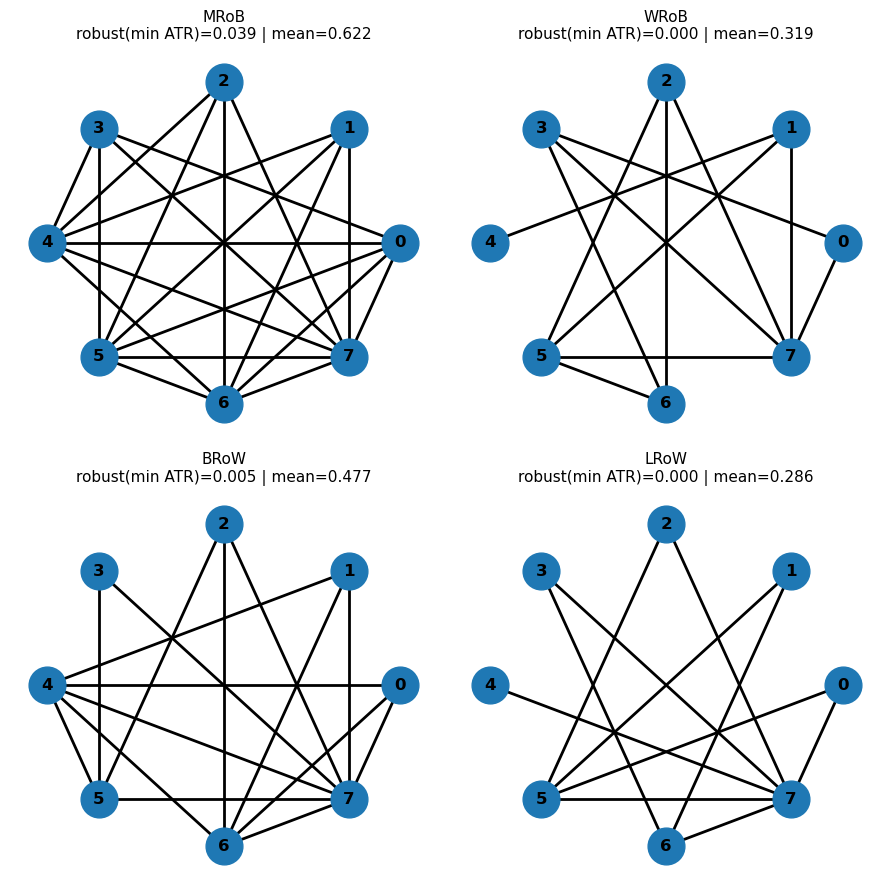

Saved to: gnn_outputs/MRoB.png, WRoB.png, BRoW.png, LRoW.png, and gnn_outputs/four_graphs.pdf


<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [27]:
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

N = 8
POS = nx.circular_layout(range(N))  # stable, easy to read

def draw_graph(G, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4,4))
    # ensure we only draw each undirected edge once
    H = nx.Graph()
    H.add_nodes_from(range(N))
    H.add_edges_from([(u,v) for u,v in G.edges() if u < v])

    nx.draw_networkx_nodes(H, POS, node_size=700, ax=ax)
    nx.draw_networkx_edges(H, POS, width=2.0, ax=ax)
    nx.draw_networkx_labels(H, POS, font_size=12, font_weight="bold", ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    return ax

def make_title(name, rec):
    return f"{name}\nrobust(min ATR)={rec['robust']:.3f} | mean={rec['mean']:.3f}"

records = {
    "MRoB": {"G": MRoB["G"], "robust": MRoB["robust"], "mean": MRoB["mean"]},
    "WRoB": {"G": WRoB["G"], "robust": WRoB["robust"], "mean": WRoB["mean"]},
    "BRoW": {"G": BRoW["G"], "robust": BRoW["robust"], "mean": BRoW["mean"]},
    "LRoW": {"G": LRoW["G"], "robust": LRoW["robust"], "mean": LRoW["mean"]},
}

fig, axes = plt.subplots(2, 2, figsize=(9,9))
for ax, (name, rec) in zip(axes.ravel(), records.items()):
    draw_graph(rec["G"], make_title(name, rec), ax=ax)
plt.tight_layout()
plt.show()

Path("gnn_outputs").mkdir(exist_ok=True)
for name, rec in records.items():
    plt.figure(figsize=(4,4))
    draw_graph(rec["G"], make_title(name, rec))
    plt.tight_layout()
    plt.savefig(f"gnn_outputs/{name}.png", dpi=200)
    plt.close()

fig, axes = plt.subplots(2, 2, figsize=(9,9))
for ax, (name, rec) in zip(axes.ravel(), records.items()):
    draw_graph(rec["G"], make_title(name, rec), ax=ax)
plt.tight_layout()
plt.savefig("gnn_outputs/four_graphs.pdf", dpi=200)
plt.close()

print("Saved to: gnn_outputs/MRoB.png, WRoB.png, BRoW.png, LRoW.png, and gnn_outputs/four_graphs.pdf")


# Resampling and Connectivity Check

This cell resamples generated graphs under a specified condition and ensures they are connected. It repeatedly draws samples, applies the MST/backbone post-process, and collects a target count of unique graphjs. Use this to make a clean set of candidates for downstream scoring or visualization.

In [ ]:
def resample_connected(model, cond_label, need=400, max_tries=2000):
    out=[]
    tries=0
    while len(out) < need and tries < max_tries:
        batch = sample_graphs(model, cond_label, n_samples=200)
        out.extend([G for G in batch if nx.is_connected(G)])
        out = out[:need]
        tries += 1
    return out

top_res = score_graphs(resample_connected(model, cond_label=1))
bot_res = score_graphs(resample_connected(model, cond_label=0))
